In [1]:
import numpy as np
np.random.seed(42)

In [2]:
X = np.random.randn(100, 1)
y = 4 + 3 * X + np.random.randn(100,1)

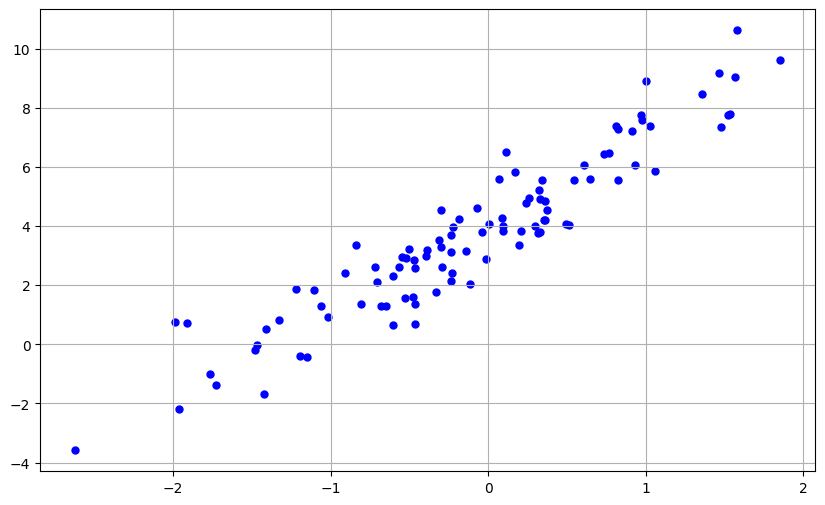

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6), dpi=100)
plt.scatter(x=X, y=y, color='b', marker='.', s=100)
plt.grid()

In [4]:
from sklearn.preprocessing import add_dummy_feature

X_b = add_dummy_feature(X)  # add x0 = 1 to each instance
theta_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y

In [5]:
len(X_b)

100

In [6]:
theta_best

array([[4.00742783],
       [2.85674284]])

In [7]:
X_new = np.array([[0], [2]])
X_new_b = add_dummy_feature(X_new)  # add x0 = 1 to each instance
y_predict = X_new_b @ theta_best
y_predict

array([[4.00742783],
       [9.72091351]])

In [8]:
X_new_b

array([[1., 0.],
       [1., 2.]])

In [9]:
np.random.seed(42)

eta = 0.1
n_epochs = 1000
m = len(X_b)

theta = np.random.randn(2,1)

for epoch in range(n_epochs):
    gradient = (2 / m) * X_b.T @(X_b @ theta - y)
    theta = theta - eta * gradient


In [10]:
theta

array([[4.00742783],
       [2.85674284]])

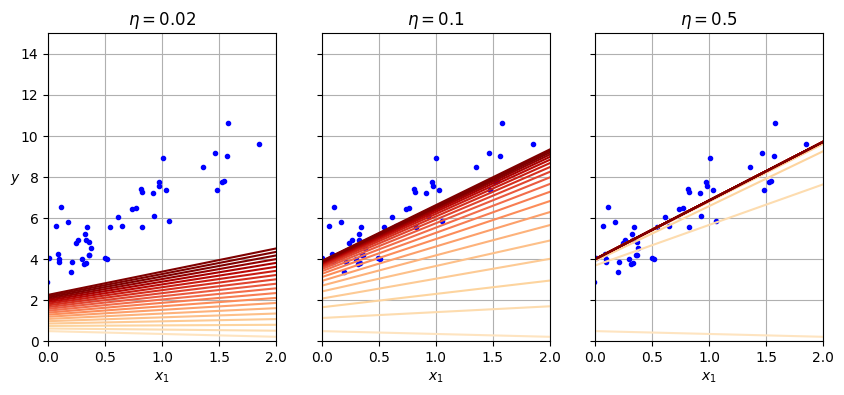

In [11]:
import matplotlib as mpl

def plot_gradient_descent(theta, eta):
    m = len(X_b)
    plt.plot(X, y, "b.")
    n_epochs = 1000
    n_shown = 20
    theta_path = []
    for epoch in range(n_epochs):
        if epoch < n_shown:
            y_predict = X_new_b @ theta
            color = mpl.colors.rgb2hex(plt.cm.OrRd(epoch / n_shown + 0.15))
            plt.plot(X_new, y_predict, linestyle="solid", color=color)
        gradients = 2 / m * X_b.T @ (X_b @ theta - y)
        theta = theta - eta * gradients
        theta_path.append(theta)
    plt.xlabel("$x_1$")
    plt.axis([0, 2, 0, 15])
    plt.grid()
    plt.title(fr"$\eta = {eta}$")
    return theta_path

np.random.seed(42)
theta = np.random.randn(2, 1)  # random initialization

plt.figure(figsize=(10, 4))
plt.subplot(131)
plot_gradient_descent(theta, eta=0.02)
plt.ylabel("$y$", rotation=0)
plt.subplot(132)
theta_path_bgd = plot_gradient_descent(theta, eta=0.1)
plt.gca().axes.yaxis.set_ticklabels([])
plt.subplot(133)
plt.gca().axes.yaxis.set_ticklabels([])
plot_gradient_descent(theta, eta=0.5)
plt.show()

## Stochastic Gradient Descent

Stochastic gradient descent picks a random instance in the training set at every step and computes the gradients based only on that single instance.

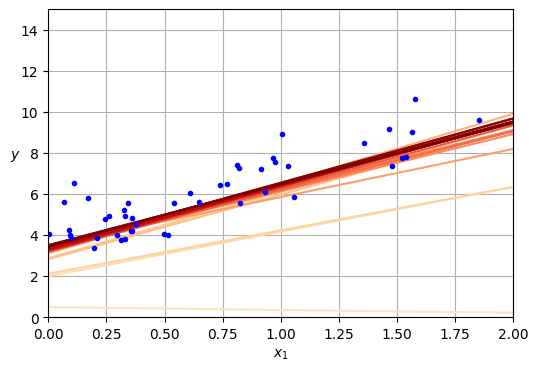

In [12]:
theta_path_sgd = []  # extra code – we need to store the path of theta in the
                     #              parameter space to plot the next figure
n_epochs = 50
t0, t1 = 5, 50  # learning schedule hyperparameters

def learning_schedule(t):
    return t0 / (t + t1)

np.random.seed(42)
theta = np.random.randn(2, 1)  # random initialization

n_shown = 20  # extra code – just needed to generate the figure below
plt.figure(figsize=(6, 4))  # extra code – not needed, just formatting

for epoch in range(n_epochs):
    for iteration in range(m):

        # extra code – these 4 lines are used to generate the figure
        if epoch == 0 and iteration < n_shown:
            y_predict = X_new_b @ theta
            color = mpl.colors.rgb2hex(plt.cm.OrRd(iteration / n_shown + 0.15))
            plt.plot(X_new, y_predict, color=color)

        random_index = np.random.randint(m)
        xi = X_b[random_index : random_index + 1]
        yi = y[random_index : random_index + 1]
        gradients = 2 * xi.T @ (xi @ theta - yi)  # for SGD, do not divide by m
        eta = learning_schedule(epoch * m + iteration)
        theta = theta - eta * gradients
        theta_path_sgd.append(theta)  # extra code – to generate the figure

# extra code – this section beautifies and saves Figure 4–10
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()
plt.show()

In [13]:
np.random.seed(42)

n_epochs = 100
t0, t1 = 5, 50

def learning_schedule(val):
    return t0/(val+t1)

theta = np.random.randn(2,1)

for epoch in range(n_epochs):
    for iteration in range(m):
        random_int = np.random.randint(m)
        xi = X_b[random_int : random_int + 1]
        yi = y[random_int: random_int + 1]

        gradient = 2 * xi.T @ (xi @ theta - yi)
        eta = learning_schedule(epoch * m + iteration)
        theta = theta - eta * gradient

In [14]:
theta

array([[4.02244933],
       [2.85107959]])

Performing linear regression using Stochastic Gradient Descent wiht Sickit-learn.

In [15]:
from sklearn.linear_model import SGDRegressor

sgd_reg = SGDRegressor(max_iter=1000, tol=1e-5, penalty=None, eta0=0.01,
                       n_iter_no_change=100, random_state=42)
sgd_reg.fit(X, y.ravel())  # y.ravel() because fit() expects 1D targets


SGDRegressor(n_iter_no_change=100, penalty=None, random_state=42, tol=1e-05)

In [16]:
sgd_reg.intercept_, sgd_reg.coef_

(array([4.0079931]), array([2.85734299]))

## Mini-batch Gradient Descent

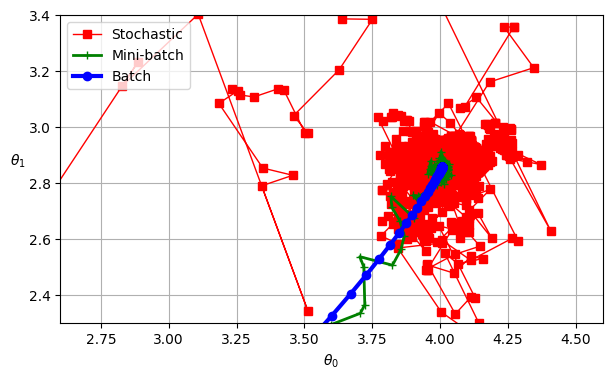

In [17]:
# extra code – this cell generates and saves Figure 4–11

from math import ceil

n_epochs = 50
minibatch_size = 20
n_batches_per_epoch = ceil(m / minibatch_size)

np.random.seed(42)
theta = np.random.randn(2, 1)  # random initialization

t0, t1 = 5, 50  # learning schedule hyperparameters

def learning_schedule(t):
    return t0 / (t + t1)

theta_path_mgd = []
for epoch in range(n_epochs):
    shuffled_indices = np.random.permutation(m)
    X_b_shuffled = X_b[shuffled_indices]
    y_shuffled = y[shuffled_indices]
    for iteration in range(0, n_batches_per_epoch):
        idx = iteration * minibatch_size
        xi = X_b_shuffled[idx : idx + minibatch_size]
        yi = y_shuffled[idx : idx + minibatch_size]
        gradients = 2 / minibatch_size * xi.T @ (xi @ theta - yi)
        eta = learning_schedule(epoch * n_batches_per_epoch + iteration)
        theta = theta - eta * gradients
        theta_path_mgd.append(theta)

theta_path_bgd = np.array(theta_path_bgd)
theta_path_sgd = np.array(theta_path_sgd)
theta_path_mgd = np.array(theta_path_mgd)

plt.figure(figsize=(7, 4))
plt.plot(theta_path_sgd[:, 0], theta_path_sgd[:, 1], "r-s", linewidth=1,
         label="Stochastic")
plt.plot(theta_path_mgd[:, 0], theta_path_mgd[:, 1], "g-+", linewidth=2,
         label="Mini-batch")
plt.plot(theta_path_bgd[:, 0], theta_path_bgd[:, 1], "b-o", linewidth=3,
         label="Batch")
plt.legend(loc="upper left")
plt.xlabel(r"$\theta_0$")
plt.ylabel(r"$\theta_1$   ", rotation=0)
plt.axis([2.6, 4.6, 2.3, 3.4])

plt.grid()
plt.show()

In [18]:
np.random.permutation(m)

array([84, 29,  4, 85, 40, 69,  0, 46, 89, 82, 22, 74, 33, 73, 91, 79, 28,
       35,  2, 51, 32, 90,  7, 42, 44, 71, 13, 53, 27, 36, 41, 88,  5, 58,
       49, 57, 24, 99, 60, 48, 50, 34,  6, 18, 95, 97, 11, 76, 15, 80, 93,
       20, 26, 25, 19, 67, 72, 31, 66, 70, 38, 75, 62, 77, 65, 14, 78, 83,
       17, 47, 12, 92,  8, 55, 52, 54, 56, 64, 16, 98, 59, 43, 23, 39,  9,
       96, 68, 61, 45, 10, 30,  1, 21, 86, 87, 37, 63, 81, 94,  3])

## Polynomial Regression

In polynomial regression, you can use a linear model to fit nonlinear data. A simple way to do this is to add powers of each feature as new features, then train a linear model on this extended set of features.

In [19]:
np.random.seed(42)
m = 100
X = 6 * np.random.randn(m, 1) - 3
y = 0.5 * X ** 2 + X + 2 + np.random.randn(m, 1)

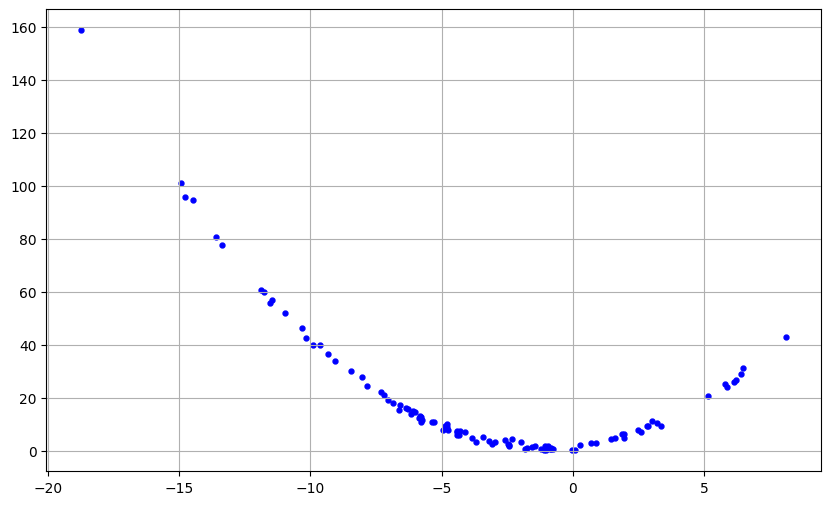

In [20]:
plt.figure(figsize = (10,6))
plt.scatter(x = X, y = y, color = 'b', marker = '.', s = 50)
plt.grid()
plt.show()

In [21]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
poly_features = PolynomialFeatures(degree=2, include_bias=False)

In [22]:
X_poly = poly_features.fit_transform(X)

In [23]:
X[0]

array([-0.01971508])

In [24]:
X_poly[0]

array([-0.01971508,  0.00038868])

In [25]:
lin_reg = LinearRegression()

In [26]:
lin_reg.fit(X_poly, y)

LinearRegression()

In [27]:
lin_reg.intercept_

array([1.87009469])

In [28]:
lin_reg.coef_

array([[1.01811444, 0.50512305]])

In [38]:
X_new = np.linspace(-6, 10, 100).reshape(100, 1)
X_poly_new = poly_features.transform(X_new)
y_new = lin_reg.predict(X_poly_new)

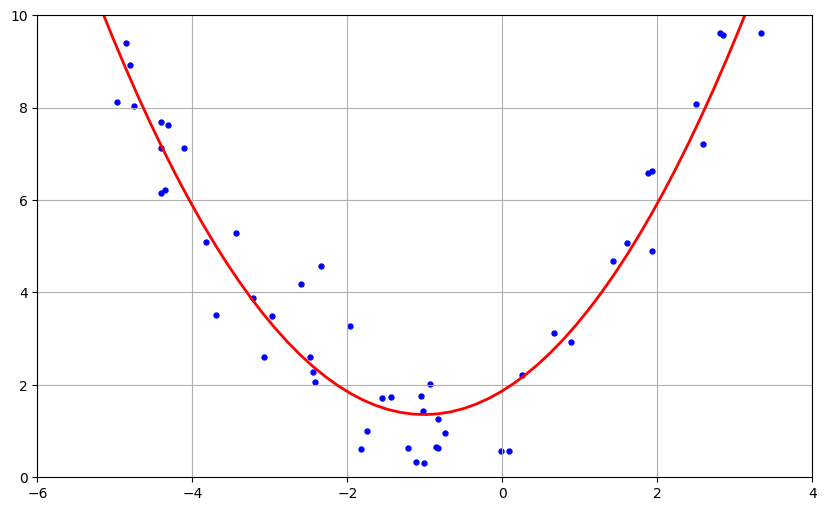

In [45]:
plt.figure(figsize = (10,6))
plt.scatter(x = X, y = y, color = 'b', marker = '.', s = 50)
plt.plot(X_new, y_new, 'r-', linewidth=2)
plt.axis([-6, 4, 0, 10])
plt.grid()
plt.show()

The model estimates $\hat{y} = 0.5x^2+1.01x+1.87$ compared to the original equation $y = 0.5x^2 + 1.0x+2 + \text{Noise}$.

## Learning Curve
Learning curves are plots of the model's training error as a function of the training iteration: just evaluate the model at regular intervals during training on both the training set and hte validation set, and plot the results.

In [66]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, valid_scores = learning_curve(LinearRegression(), X, y, train_sizes=np.linspace(0.01, 1, 40), cv=5, scoring = 'neg_root_mean_squared_error')

In [67]:
train_scores = -train_scores.mean(axis=1)
valid_scores = -valid_scores.mean(axis=1)

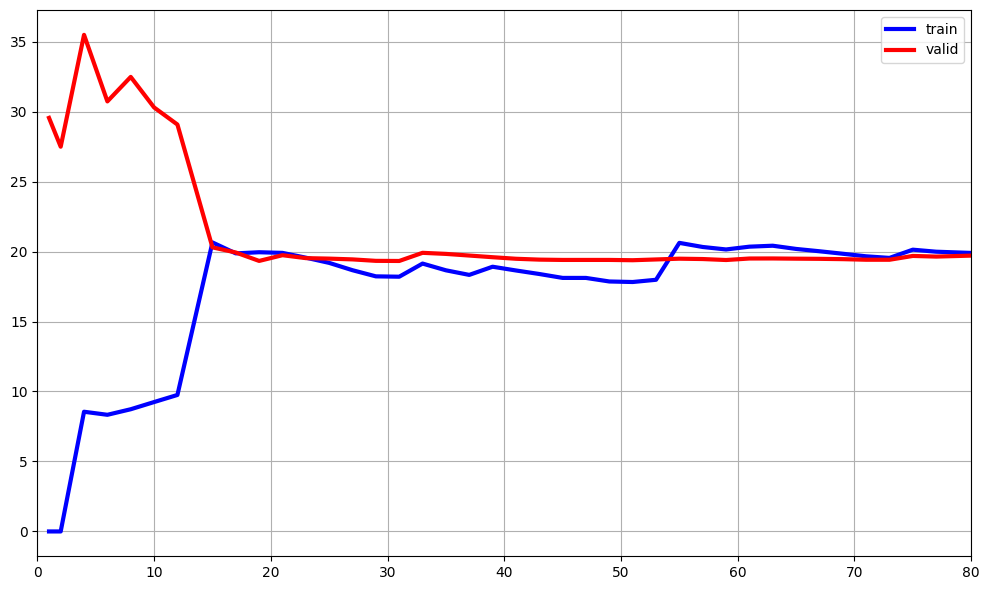

In [ ]:
plt.figure(figsize=(10,6), dpi=100)
plt.plot(train_sizes, train_scores, 'r-', linewidth=3, label='train')
plt.plot(train_sizes, valid_scores, 'b-', linewidth=3, label ='valid')
plt.grid()
plt.legend(loc= 'upper right')
plt.xlim([0,80])
plt.tight_layout()
plt.show()

**This model is underfitting**. Let us look at the 10-degree polynomial.

In [91]:
from sklearn.pipeline import make_pipeline

polynomial_regression = make_pipeline(PolynomialFeatures(degree=10,include_bias=False), LinearRegression())

train_sizes, train_scores, valid_scores = learning_curve(polynomial_regression, X, y, train_sizes=np.linspace(0.01, 1.0, 40), cv=5, scoring='neg_root_mean_squared_error')


In [92]:
train_scores = -train_scores.mean(axis=1)
valid_scores = -valid_scores.mean(axis=1)

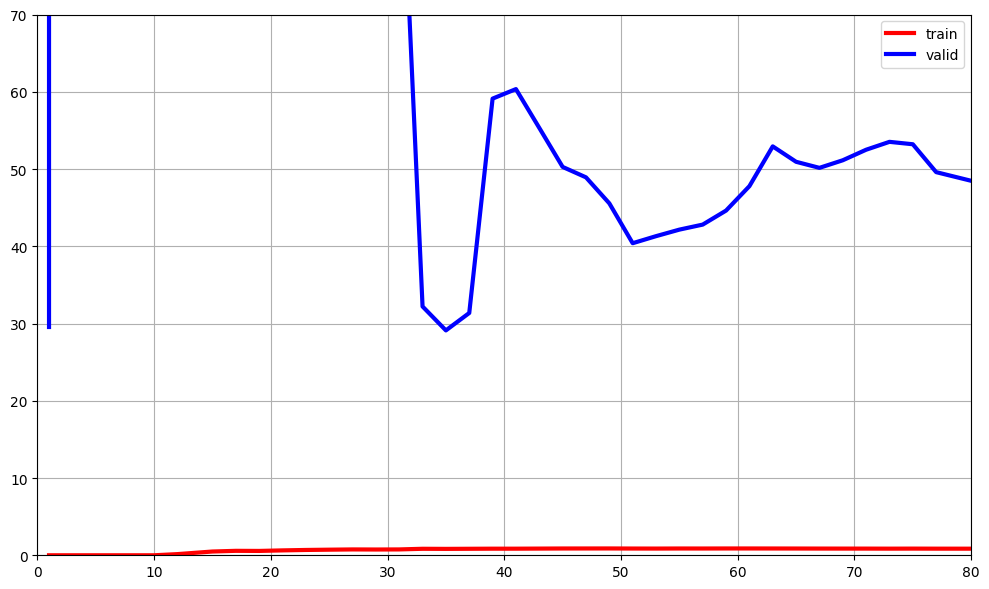

In [107]:
plt.figure(figsize=(10,6), dpi=100)
plt.plot(train_sizes, train_scores, 'r-', linewidth=3, label='train')
plt.plot(train_sizes, valid_scores, 'b-', linewidth=3, label ='valid')
plt.grid()
plt.legend(loc= 'upper right')
plt.xlim([0,80])
plt.ylim([0,70])
plt.tight_layout()
plt.show()

**This overfits the data**

**The Bias/Variance Trade-Off**  
- **Bias**: Error from wrong assumptions (e.g., assuming linear when data is quadratic). High bias leads to underfitting.  
- **Variance**: Error from sensitivity to small variations. Complex models (e.g., high-degree polynomials) have high variance, leading to overfitting.  
- **Irreducible error**: Error from inherent noise in the data, only reducible by improving data quality (e.g., fixing sensors, removing outliers).  

Increasing model complexity lowers bias but raises variance; reducing complexity lowers variance but raises bias. This trade-off explains the balance needed between underfitting and overfitting.

## Regularized Linear Model
### Ridge Regression

In [108]:
# extra code – we've done this type of generation several times before
np.random.seed(42)
m = 20
X = 3 * np.random.rand(m, 1)
y = 1 + 0.5 * X + np.random.randn(m, 1) / 1.5
X_new = np.linspace(0, 3, 100).reshape(100, 1)

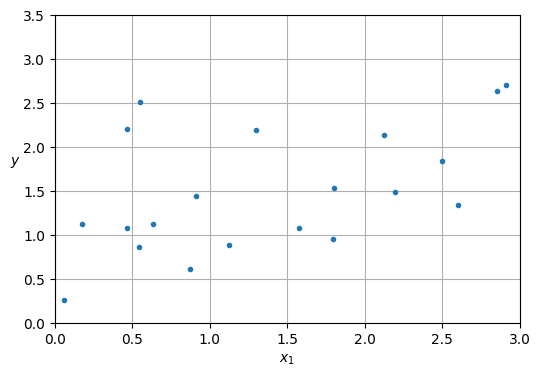

In [109]:
# extra code – a quick peek at the dataset we just generated
plt.figure(figsize=(6, 4))
plt.plot(X, y, ".")
plt.xlabel("$x_1$")
plt.ylabel("$y$  ", rotation=0)
plt.axis([0, 3, 0, 3.5])
plt.grid()
plt.show()

In [110]:
from sklearn.linear_model import Ridge

ridge_reg = Ridge(alpha=0.1, solver="cholesky")
ridge_reg.fit(X, y)
ridge_reg.predict([[1.5]])

array([1.55325833])

We can also use stochastic gradient descent with the same regularization hyperparameter.

In [ ]:
sgd_reg = SGDRegressor(penalty="l2", alpha=0.1 / m, tol=None,
                       max_iter=1000, eta0=0.01, random_state=42)
sgd_reg.fit(X, y.ravel())  # y.ravel() because fit() expects 1D targets
sgd_reg.predict([[1.5]])

array([1.55302613])

The penalty hyperparameter sets the type of regularization term to use. Specifying `l2` indicates that we want SGD to add a regularization term to the MSE cost function equal to alpha times the square of the $\ell_2$ norm of the weight vector. This is the same with Ridge regression but without dividing by `m`. 

### Lasso Regression

Least absolute shrinkage and selection operator regression (lasso regression) is another regularized version of linear regression. The key difference of lasso regression from ridge regression is that it uses $\ell_2$ norm instead of $\ell_1$.

In [ ]:
from sklearn.linear_model import Lasso

lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X, y)
lasso_reg.predict([[1.5]])

### Elastic Net Regression

Elastic Net regression is a **middle ground** between Ridge regression and Lasso regression. It uses a **weighted sum** of both Ridge’s ($\ell_2$) and Lasso’s ($\ell_1$) regularization terms, with a **mix ratio** $r$.  That is, when $r=0$, it is equivalent to Ridge regression.  When $r=1$, it is equivalent to Lasso regression.

In [112]:
from sklearn.linear_model import ElasticNet

elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic_net.fit(X, y)
elastic_net.predict([[1.5]])

array([1.54333232])

## Early Stopping

In [123]:
try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error

    def root_mean_squared_error(labels, predictions):
        return mean_squared_error(labels, predictions, squared=False)

In [134]:
from copy import deepcopy
from sklearn.preprocessing import StandardScaler

# extra code – creates the same quadratic dataset as earlier and splits it
np.random.seed(42)
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X ** 2 + X + 2 + np.random.randn(m, 1)
X_train, y_train = X[: m // 2], y[: m // 2, 0]
X_valid, y_valid = X[m // 2 :], y[m // 2 :, 0]

preprocessing = make_pipeline(PolynomialFeatures(degree=90, include_bias=False),
                              StandardScaler())
X_train_prep = preprocessing.fit_transform(X_train)
X_valid_prep = preprocessing.transform(X_valid)
sgd_reg = SGDRegressor(penalty=None, eta0=0.002, random_state=42)
n_epochs = 500
best_valid_rmse = float('inf')
train_errors, val_errors = [], []  # extra code – it's for the figure below

for epoch in range(n_epochs):
    sgd_reg.partial_fit(X_train_prep, y_train)
    y_valid_predict = sgd_reg.predict(X_valid_prep)
    val_error = root_mean_squared_error(y_valid, y_valid_predict)
    if val_error < best_valid_rmse:
        best_valid_rmse = val_error
        best_model = deepcopy(sgd_reg)

    # extra code – we evaluate the train error and save it for the figure
    y_train_predict = sgd_reg.predict(X_train_prep)
    train_error = root_mean_squared_error(y_train, y_train_predict)
    val_errors.append(val_error)
    train_errors.append(train_error)

## Logistic Regression

**Logistic regression** (also called *logit regression*) is a regression algorithm often used for classification. It estimates the probability that an instance belongs to a class (positive class = 1, negative class = 0). If the probability is greater than a threshold (usually 50%), the model predicts class 1; otherwise, class 0. This makes it a **binary classifier**.

In [135]:
from sklearn.datasets import load_iris
iris = load_iris(as_frame=True)

list(iris)

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [136]:
iris.data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [137]:
iris.target.head()

0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

In [138]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split